In [1]:
import os
import sys
sys.path.append('../')
import numpy as np
import open3d as o3d
import torch
import seaborn as sns
import json
import matplotlib.pyplot as plt
from scene.gaussian_model import GaussianModel, BasicPointCloud
from scene.videoartgs import VideoArtGS as ArtGS
from utils.metrics import *
from gaussian_renderer import render_gsplat as render

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/yuliu/anaconda3/envs/artgsv2/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yuliu/anaconda3/envs/artgsv2/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def visualize_point_cloud(xyz, rgb=None, save_path=None):
    """
    xyz: (N, 3) numpy array
    rgb: (N, 3) numpy array
    """
    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(xyz)
    if rgb is not None:
        point_cloud.colors = o3d.utility.Vector3dVector(rgb)
    o3d.visualization.draw_geometries([point_cloud], )
    if save_path is not None:
        o3d.io.write_point_cloud(save_path, point_cloud)


class Args(object):
    def __init__(self):
        self.slot_size = 32
        self.joint_types = None
        self.num_slots = 0
        self.gumbel = True
        self.scale_factor = 1.
        self.use_art_type_prior = True
        self.shift_weight = 0.1
        self.tau_decay_steps = 10000
        self.time_model_type = 'predict'
        self.points_direction = False
        self.use_motion_grid = False
        self.refine_stage = True
        self.mask_inv = True
        self.seg_type = 'hybrid'

In [ ]:
dataset = "artgs"
# dataset = "v2a"
subset = "sapien"
subset = "realscan"
data_dir = f"../data/{dataset}/{subset}"
model_dir = f"../outputs/{dataset}/{subset}"

In [4]:
def plot_thetas(thetas):
    # thetas: (N, T), plot N lines, each line has T points
    plt.figure(figsize=(5, 2))
    for i in range(thetas.shape[0]):
        plt.plot(thetas[i])
    plt.show()

In [5]:
def vis_artgs(scene, cano_iter=20000, cano_type='pcd', deform_iter=20000, deform_type='init', model_name='base', plot_theta=False, vis_pc=False):
    joint_infos = json.load(open(f'{data_dir}/{scene}/joint_infos.json', 'r'))
    joint_types = [joint_info['joint_type'] for joint_info in joint_infos]
    args = Args()
    args.joint_types = joint_types
    args.num_slots = len(args.joint_types)
    pallete = np.array(sns.color_palette("hls", args.num_slots))
    pallete[0] = [0.5, 0.5, 0.5]
    # pallete[0] = [1, 1, 1]

    gs = GaussianModel(3, 0)
    
    if cano_type == 'pcd':
        pcd_path = f'{data_dir}/{scene}/point_cloud.ply'
        pcd = o3d.io.read_point_cloud(pcd_path)
        xyz, rgb = np.asarray(pcd.points), np.asarray(pcd.colors)
        gs.create_from_pcd(BasicPointCloud(xyz, rgb, np.zeros_like(xyz)), print_info=False)
    elif cano_type == 'init':
        gs_path = f'{model_dir}/{scene}/init/point_cloud/iteration_{cano_iter}/point_cloud.ply'
        gs.load_ply(gs_path)
    elif cano_type == 'opt':
        gs_path = f'{model_dir}/{scene}/{model_name}/point_cloud/iteration_{cano_iter}/point_cloud.ply'
        gs.load_ply(gs_path)
    elif cano_type == 'track':
        track_data = np.load(f"{data_dir}/{scene}/{scene}_filtered.npz")
        track3d = torch.from_numpy(track_data["coords"]).float().cuda()[0]
        gs.create_from_pcd(BasicPointCloud(track3d.cpu().numpy(), np.zeros_like(track3d.cpu().numpy()), np.zeros_like(track3d.cpu().numpy())), print_info=False)
    print(gs.get_xyz.shape)
    deform = ArtGS(args).cuda()
    if deform_type == 'init':
        deform_path = f'{model_dir}/{scene}/{model_name}/deform/iteration_{deform_iter}/deform.pth'
        deform.load_state_dict(torch.load(deform_path, weights_only=True), strict=False)
    elif deform_type == 'track':
        joint_infos = json.load(open(f"{data_dir}/{scene}/joint_infos.json", "r"))
        deform.init_from_joint_info(joint_infos, init_joint_info='track')
    elif deform_type == 'opt':
        deform_path = f'{model_dir}/{scene}/{model_name}/deform/iteration_{deform_iter}/deform.pth'
        deform.load_state_dict(torch.load(deform_path, weights_only=True), strict=False)
    # print('load deform from', deform_path)
    deform.update(10000)
    deform.eval()   

    sub_sample = 1
    n_dyn_frames = (args.num_slots - 1) * 60
    with torch.no_grad():
        xyz = gs.get_xyz
        mask = deform.get_mask(xyz)
        xyz = xyz.cpu().numpy()[::sub_sample]
        _, _, theta = deform.art_model(torch.arange(n_dyn_frames)[:, None].cuda() / n_dyn_frames)
        t = torch.tensor([(n_dyn_frames - 80) / n_dyn_frames]).cuda()
        # xt = deform.one_transform(gs, t, None, is_training=False)['xt'][::sub_sample]
        # xyz = xt.cpu().numpy()
        # xc, mask = deform.obs2cano(xt[None], t[None], is_training=False)
        # xyz = xc.squeeze(0).cpu().numpy()
        mask = mask.argmax(1).cpu().numpy()
        # print(np.unique(mask))
        # mask = gs.get_group_id.cpu().numpy()
        color = pallete[mask]
        center = deform.seg_model.center.detach().cpu().numpy()
        center1 = np.stack([xyz[mask == i].mean(0) for i in range(args.num_slots)])
        center = np.concatenate([center1[0:1], center], 0)
        xyz_center = (center[None] + np.random.randn(1000, center.shape[0], 3) * 0.01).reshape(-1, 3)
        rgb_center = pallete[:center.shape[0]][None].repeat(1000, 0).reshape(-1, 3)
        joint_info_list = deform.get_joint_param()
        # centers = deform.seg_model.center.detach().cpu().numpy()
        axises = []
        for i, joint_info in enumerate(joint_info_list):
            direction = joint_info['direction']
            pos = joint_info['origin']
            if joint_types[i+1] == 'p':
                pos = center[i+1]
            pos += direction * np.dot(direction, center[i+1] - pos)
            # visualize the joint
            axis_points = pos[None] + direction[None] * np.linspace(-2, 2, 5000)[:, None]
            axis_colors = pallete[i+1][None].repeat(5000, 0)
            axis = np.concatenate([axis_points, axis_colors], axis=1)
            axises.append(axis)
        axis = np.concatenate(axises)
        xyz_vis = np.concatenate([xyz, xyz_center])
        color_vis = np.concatenate([color, rgb_center])


        visualize_point_cloud(xyz_vis, color_vis)
        visualize_point_cloud(axis[:, :3], axis[:, 3:])
        xyz_vis = np.concatenate([xyz_vis, axis[:, :3]])
        color_vis = np.concatenate([color_vis, axis[:, 3:]])
        if plot_theta:
            plot_thetas(theta[1:].cpu().numpy())
        if vis_pc:
            visualize_point_cloud(xyz_vis, color_vis)

        gt_info_list = read_gt(f'{data_dir}/{scene}/gt/mobility_v2.json')
        results_list, _ = eval_axis_and_state_all(joint_info_list[1:], gt_info_list)
        r = np.array(results_list).sum(0)
        # print(r)
        return r
        # print(results_list)

torch.Size([10088, 3])
Init VideoArtGS from joint info.
init_center: True, init_joint_info: track


/tmp/ipykernel_938667/2774365722.py:60: RuntimeWarning: Mean of empty slice.
  center1 = np.stack([xyz[mask == i].mean(0) for i in range(args.num_slots)])
/home/yuliu/anaconda3/envs/artgsv2/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


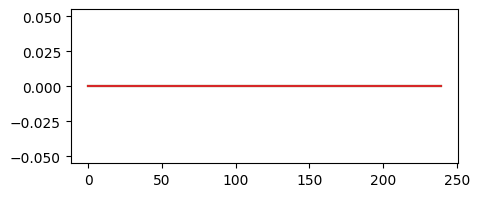

[Errno 2] No such file or directory: '../data/artgs/realscan/box_4r/gt/mobility_v2.json'


: 

In [ ]:
scenes = sorted(os.listdir(data_dir))
scene_names = [os.path.basename(s) for s in scenes if os.path.isdir(os.path.join(data_dir, s))]
rets = {}
# scene_names = ('47648', '10211', '102255', '103111')
cano_type = 'pcd'
deform_type = 'track'
# model_name = 'init_maskinv_nothetaonly'
# model_name = 'init_new'
model_name = 'init'
cano_iter = 20000
deform_iter = 1000
scene_names = ['103811_new', '154_new', '168_new', '30666_new', '100481_new']
scene_names = ['100481_new']
# scene_names = ['30666_new']
# scene_names = ['mac_1r']
# scene_names = ['cab1']
scene_names = ['box_4r']
# scene_names = ['cabinet_2r_4p']
# scene_names = ['coffeemachine_2r', 'mac_1r', 'chair_1r', 'microwave_1r', 'cab1']

for scene_name in scene_names:
    # print(scene_name)
    # r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name) 
    try:
        # r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name, plot_theta=False, vis_pc=False) 
        r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name, plot_theta=True, vis_pc=True) 
        rets[scene_name] = r.mean()
        print(scene_name, r)
    except Exception as e:
        print(e)
        continue
# print(rets)

torch.Size([285083, 3])


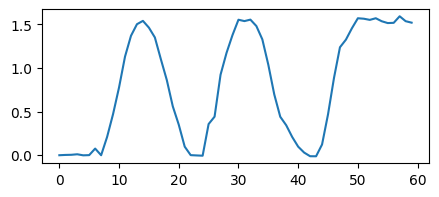

[Errno 2] No such file or directory: '../data/artgs/realscan/microwave1/gt/mobility_v2.json'


In [15]:
scenes = sorted(os.listdir(data_dir))
scene_names = [os.path.basename(s) for s in scenes if os.path.isdir(os.path.join(data_dir, s))]
rets = {}
# scene_names = ('47648', '10211', '102255', '103111')
cano_type = 'opt'
deform_type = 'opt'
model_name = 'nothetaonly'
model_name = 'thetaonly'
model_name = 'base_tau10000_soft'
model_name = 'base_mi_nt_res1_'
model_name = 'base_notrack'
model_name = 'base_mi_nt'
model_name = 'demo1'
# model_name = 'base_maskinv_nothetaonly1'
cano_iter = 20000
deform_iter = 20000
scene_names = ['103811_new', '154_new', '168_new', '30666_new', '100481_new']
scenes=('1280_new' '103811_new' '168_new' '45612_new' '31249_new')
scenes=('25493_new' '47648_new' '45194_new')
scene_names = ['31249_new']
# scene_names = ['cab1']
# scene_names = ['mac_1r', 'microwave_1r', 'coffeemachine_2r', 'chair_1r']
# scene_names = ['cabinet_2r_2p', 'printer_2r_1p']
scene_names = ['microwave1']
for scene_name in scene_names:
    # if 'new' not in scene_name:
    #     continue
    # print(scene_name)
    # r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name) 
    try:
        # r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name, plot_theta=False, vis_pc=False) 
        r = vis_artgs(scene_name, cano_iter, cano_type, deform_iter, deform_type, model_name, plot_theta=True, vis_pc=True) 
        rets[scene_name] = r.mean()
        print(scene_name, r)
    except Exception as e:
        print(e)
        continue
# print(rets)

In [7]:
scene_name = '45194_new'
data_dir = "../data/videoartgs/realscan"
scene_name = 'microwave'
scene_name = 'cab_2r'
# scene_name = '103811_new'
track_data = np.load(f"{data_dir}/{scene_name}/{scene_name}_filtered_vis.npz")
track3d = track_data["coords"][0]
# motion_type = torch.from_numpy(track_data["motion_type"]).cuda()
mask_ids = track_data["mask_ids"]
print(np.unique(mask_ids))
pallete = np.array(np.clip(np.random.rand(100, 3) + 0.1, 0, 1))
pallete[0] = [0, 0, 0]
pallete = pallete[mask_ids]
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(track3d)
pcd.colors = o3d.utility.Vector3dVector(pallete)
o3d.visualization.draw_geometries([pcd])
# for i in range(1, mask_ids.max() + 1):
#     m = (mask_ids == 0) | (mask_ids == i)
#     pcd = o3d.geometry.PointCloud()
#     pcd.points = o3d.utility.Vector3dVector(track3d[m])
#     pcd.colors = o3d.utility.Vector3dVector(pallete[m])
#     o3d.visualization.draw_geometries([pcd])

[0 1 2]


In [38]:
print(rets)

{20000: {'47648': 26.61064682635307, '10211': 3.949503673382903, '102255': 2.828974392051831, '103111': 1.885165472059751}}


## Visualize Part Segmentation and Joint Axis

In [12]:
scene = 'cab1'
data_dir = f'../data/artgs/realscan'
pcd_data = np.load(f'{data_dir}/{scene}/pcd_frames.npz', allow_pickle=True)
xyz = pcd_data['xyz']
color = pcd_data['color']
pts = np.concatenate([xyz, color], axis=-1)
idxs = pcd_data['start_idx']
print(len(idxs))
# pts = pts[idxs[0]:idxs[1]]
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts[:, :3])
pcd.colors = o3d.utility.Vector3dVector(pts[:, 3:6])
o3d.visualization.draw_geometries([pcd])
# pcd = o3d.io.read_point_cloud(f'./data/artgs/sapien_mono/real_microwave/point_cloud.ply')
# color = np.asarray(pcd.colors)
# pts = np.asarray(pcd.points)
# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(pts)
# pcd.colors = o3d.utility.Vector3dVector(color)
# o3d.visualization.draw_geometries([pcd])

144


In [68]:
joint_infos = json.load(open(f'{data_dir}/{scene}/joint_infos.json', 'r'))
joint_types = [joint_info['joint_type'] for joint_info in joint_infos]
args = Args()
args.joint_types = joint_types
args.num_slots = len(args.joint_types)
pallete = np.array(sns.color_palette("hls", 10))
pallete[0] = [0, 0, 0]
deform = ArtGS(args).cuda()
model_name = 'init'
# model_name = 'init_novismask'
deform_iter = 10000
deform_path = f'{model_dir}/{scene}/{model_name}/deform/iteration_{deform_iter}/deform.pth'
deform.load_state_dict(torch.load(deform_path, weights_only=True), strict=False)

<All keys matched successfully>

In [70]:
pts_cano = []
start_idx = 100
# end_idx = len(idxs)
# start_idx = 210
end_idx = start_idx + 143
with torch.no_grad():
    for i in range(len(idxs)-1):
        pts_frame = pts[idxs[i]:idxs[i+1]]
        xt = torch.from_numpy(pts_frame[:, :3]).cuda().float()
        xc, mask = deform.obs2cano(xt, torch.tensor([i / 143]).cuda())
        xc = xc.cpu().numpy()
        xc = np.concatenate([xc, pts_frame[:, :3]], axis=0)
        mask = mask.argmax(axis=-1).cpu().numpy()
        color = pallete[mask]
        color1 = pallete[mask + 5]
        color = np.concatenate([color, color1], axis=0) 
        p = np.concatenate([xc, color], axis=-1)
        id = 1
        m = np.concatenate([mask==id, mask==id], axis=0)
        pts_cano.append(p[m])
        # pts_cano.append(np.concatenate([xyz.cpu().numpy(), pts_frame[:, 3:6]], axis=-1))
        # pcd_cano = o3d.geometry.PointCloud()
        # pcd_cano.points = o3d.utility.Vector3dVector(np.concatenate([xc, pts_frame[:, :3]], axis=0))
        # pcd_cano.colors = o3d.utility.Vector3dVector(np.concatenate([np.zeros_like(xc), pts_frame[:, 3:6]], axis=0))
        # o3d.visualization.draw_geometries([pcd_cano])
pts_cano = np.concatenate(pts_cano, 0)
pcd_cano = o3d.geometry.PointCloud()
pcd_cano.points = o3d.utility.Vector3dVector(pts_cano[:, :3])
pcd_cano.colors = o3d.utility.Vector3dVector(pts_cano[:, 3:6])
pcd_cano = pcd_cano.voxel_down_sample(voxel_size=0.001)
print(len(pcd_cano.points))
o3d.visualization.draw_geometries([pcd_cano])
# o3d.io.write_point_cloud(f'{data_dir}/cano_pcd.ply', pcd_cano)

177793
